<a href="https://colab.research.google.com/github/acarbegum/LLM-Fine-Tuning/blob/main/Saliency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

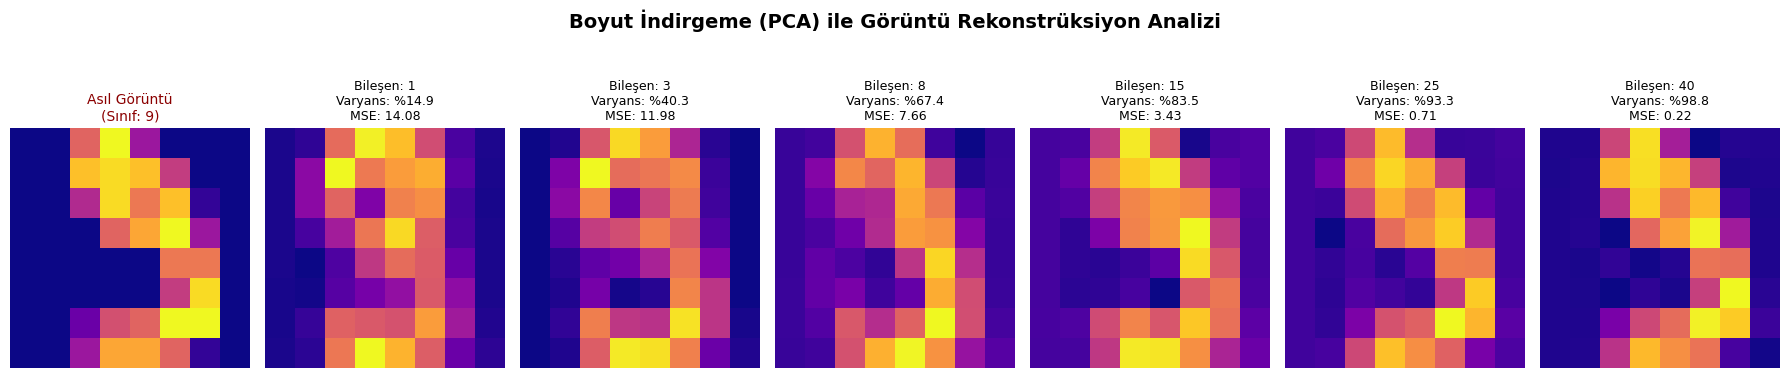

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# 1. Veri Setini Yükleme (Colab'da doğrudan çalışması için)
digits = load_digits()
X_flat = digits.data
y_digits = digits.target

# 2. Parametreleri Değiştiriyoruz
component_options = [1, 3, 8, 15, 25, 40]  # Yeni bileşen sayıları
chosen_img_idx = 105                        # Farklı bir örnek resmi seçtik
original_img = X_flat[chosen_img_idx]      # Seçilen orijinal resim

# 3. Grafik Alanını Oluşturma
fig, axes = plt.subplots(1, len(component_options) + 1, figsize=(18, 4))

# Orijinal Resmi Çizdirme
axes[0].imshow(original_img.reshape(8, 8), cmap='plasma', interpolation='nearest')
axes[0].set_title(f"Asıl Görüntü\n(Sınıf: {y_digits[chosen_img_idx]})", fontsize=10, color='darkred')
axes[0].axis('off')

# PCA Döngüsü - Farklı bileşen sayıları için sıkıştırma ve geri yükleme
for idx, n in enumerate(component_options):
    # PCA modelini tanımla ve eğit
    pca = PCA(n_components=n)
    pca.fit(X_flat)

    # Sıkıştır ve ardından orijinal boyuta geri projeksiyon yap (inverse_transform)
    compressed_data = pca.transform(X_flat[chosen_img_idx : chosen_img_idx + 1])
    reconstructed_data = pca.inverse_transform(compressed_data)[0]

    # İstatistikleri Hesaplama (MSE ve Açıklanan Varyans Oranı)
    mean_sq_error = np.mean((original_img - reconstructed_data) ** 2)
    explained_variance = np.sum(pca.explained_variance_ratio_) * 100

    # Geri Yapılandırılmış Resmi Çizdirme
    axes[idx + 1].imshow(reconstructed_data.reshape(8, 8), cmap='plasma', interpolation='nearest')
    axes[idx + 1].set_title(f"Bileşen: {n}\nVaryans: %{explained_variance:.1f}\nMSE: {mean_sq_error:.2f}", fontsize=9)
    axes[idx + 1].axis('off')

# Genel Grafik Başlığı
plt.suptitle("Boyut İndirgeme (PCA) ile Görüntü Rekonstrüksiyon Analizi", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Adım 1: PCA ile ön işleme yapılıyor (25 boyuta indiriliyor)...
  [Yeni] PCA Çıktı Boyutu: (1797, 25)
Adım 2: t-SNE optimizasyonu başlatılıyor...
  [Yeni] t-SNE Çıktı Boyutu: (1797, 2)


/tmp/ipykernel_2050/3496636313.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('Spectral', 10)


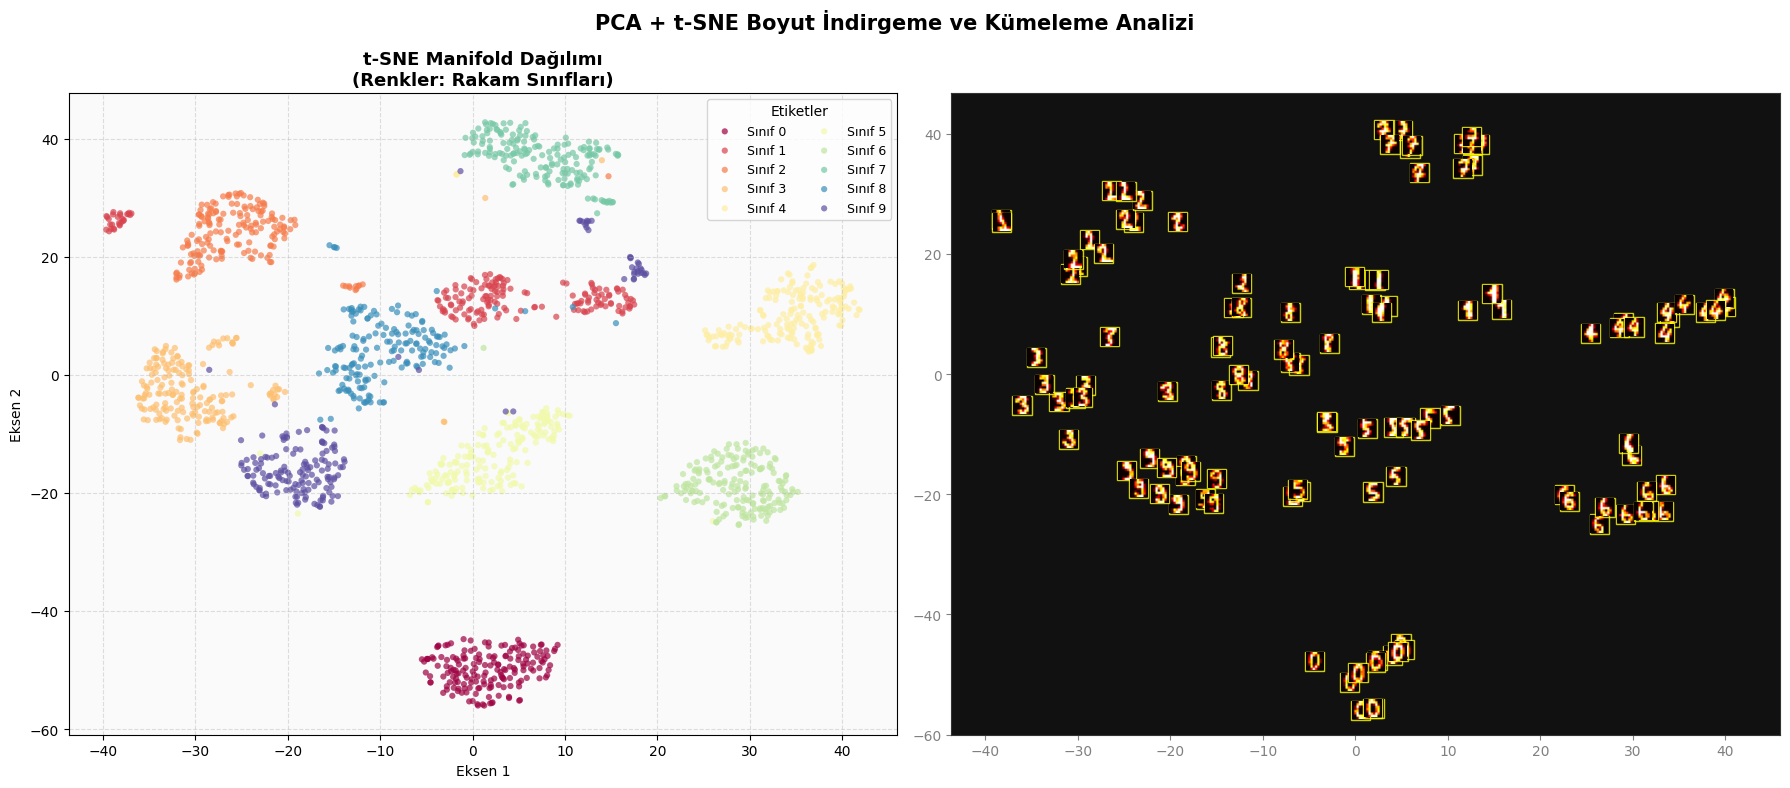


🚀 Analiz tamamlandı. Farklı renk kümelerinin ayrışması verinin ayırt edilebilirliğini gösterir.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

# 1. Veri Setini Yükleme (Colab uyumluluğu için)
digits = load_digits()
X_flat = digits.data
y_digits = digits.target
X_digits = digits.images  # Orijinal 8x8 görüntüler

# ── Adım 1: PCA ile Boyut Azaltma (Yarışmacı Değerler) ────────────────────────
print("Adım 1: PCA ile ön işleme yapılıyor (25 boyuta indiriliyor)...")
pca_pre = PCA(n_components=25, random_state=55)
X_pca = pca_pre.fit_transform(X_flat)
print(f"  [Yeni] PCA Çıktı Boyutu: {X_pca.shape}")

# ── Adım 2: t-SNE ile Manifest Manifold Dönüşümü ──────────────────────────────
print("Adım 2: t-SNE optimizasyonu başlatılıyor...")
tsne_model = TSNE(
    n_components=2,
    perplexity=40,         # Yoğunluk odağını değiştirdik
    max_iter=900,          # İterasyon güncellendi
    random_state=123,      # Farklı bir dağılım için seed değişti
    learning_rate='auto',
    init='pca'
)
X_tsne = tsne_model.fit_transform(X_pca)
print(f"  [Yeni] t-SNE Çıktı Boyutu: {X_tsne.shape}")

# ── Görselleştirme ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 10 benzersiz sınıf için yeni renk haritası
color_map = plt.cm.get_cmap('Spectral', 10)

# Sol Grafik: Noktasal Dağılım (Scatter Plot)
axes[0].set_facecolor('#fafafa')
for digit in range(10):
    mask = (y_digits == digit)
    axes[0].scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        color=color_map(digit),
        label=f"Sınıf {digit}",
        alpha=0.7,
        s=20,
        edgecolors='none'
    )

axes[0].set_title("t-SNE Manifold Dağılımı\n(Renkler: Rakam Sınıfları)", fontsize=13, fontweight='bold')
axes[0].legend(title="Etiketler", ncol=2, fontsize=9, loc='best')
axes[0].set_xlabel("Eksen 1")
axes[0].set_ylabel("Eksen 2")
axes[0].grid(True, linestyle='--', alpha=0.4)

# Sağ Grafik: Noktalar Üzerine Gerçek Resim Projeksiyonu
# KOYU TEMADA KONTRAST ARTTIRILDI
axes[1].set_facecolor('#111111')  # Neredeyse tamamen siyah arka plan
axes[1].set_title("t-SNE Haritası Üzerinde Gerçek Görüntüler\n(Sınıf Rengine Göre Çerçevelenmiş)",
                  fontsize=13, fontweight='bold', color='white')

# Farklı bir random generator ile örnekleme yapıyoruz
rng = np.random.default_rng(42)
samples_per_class = 12  # Grafik netliği için örnek sayısını 12 yaptık

for digit in range(10):
    class_indices = np.where(y_digits == digit)[0]
    chosen_indices = rng.choice(class_indices, size=min(samples_per_class, len(class_indices)), replace=False)

    for idx in chosen_indices:
        img = X_digits[idx]
        x_pos, y_pos = X_tsne[idx, 0], X_tsne[idx, 1]

        # Sınıfa ait rengi al (Sınıfın Spectral rengini kullan)
        border_color = color_map(digit)[:3]

        # Görüntü kutusunu oluşturma
        # GÖRÜNÜRLÜĞÜ ARTTIRMAK İÇİN 'HOT' PALETİ VE SARİ ÇERÇEVE
        img_box = OffsetImage(img, zoom=1.6, cmap='hot')  # Görüntüyü 'hot' paleti ile oluştur (parlak renkler)
        ann_box = AnnotationBbox(
            img_box, (x_pos, y_pos),
            frameon=True,
            bboxprops=dict(
                boxstyle='square,pad=0.05',
                facecolor='none',  # Şeffaf iç alan
                edgecolor='yellow', # Parlak sarı çerçeve
                linewidth=1.0,
                alpha=0.8 # Hafif şeffaf çerçeve
            )
        )
        axes[1].add_artist(ann_box)

# Sınırları otomatik ölçeklendirme
axes[1].set_xlim(X_tsne[:, 0].min() - 4, X_tsne[:, 0].max() + 4)
axes[1].set_ylim(X_tsne[:, 1].min() - 4, X_tsne[:, 1].max() + 4)

# Koyu tema eksen ayarları
axes[1].tick_params(colors='gray')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#333333')

plt.suptitle("PCA + t-SNE Boyut İndirgeme ve Kümeleme Analizi", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n🚀 Analiz tamamlandı. Farklı renk kümelerinin ayrışması verinin ayırt edilebilirliğini gösterir.")

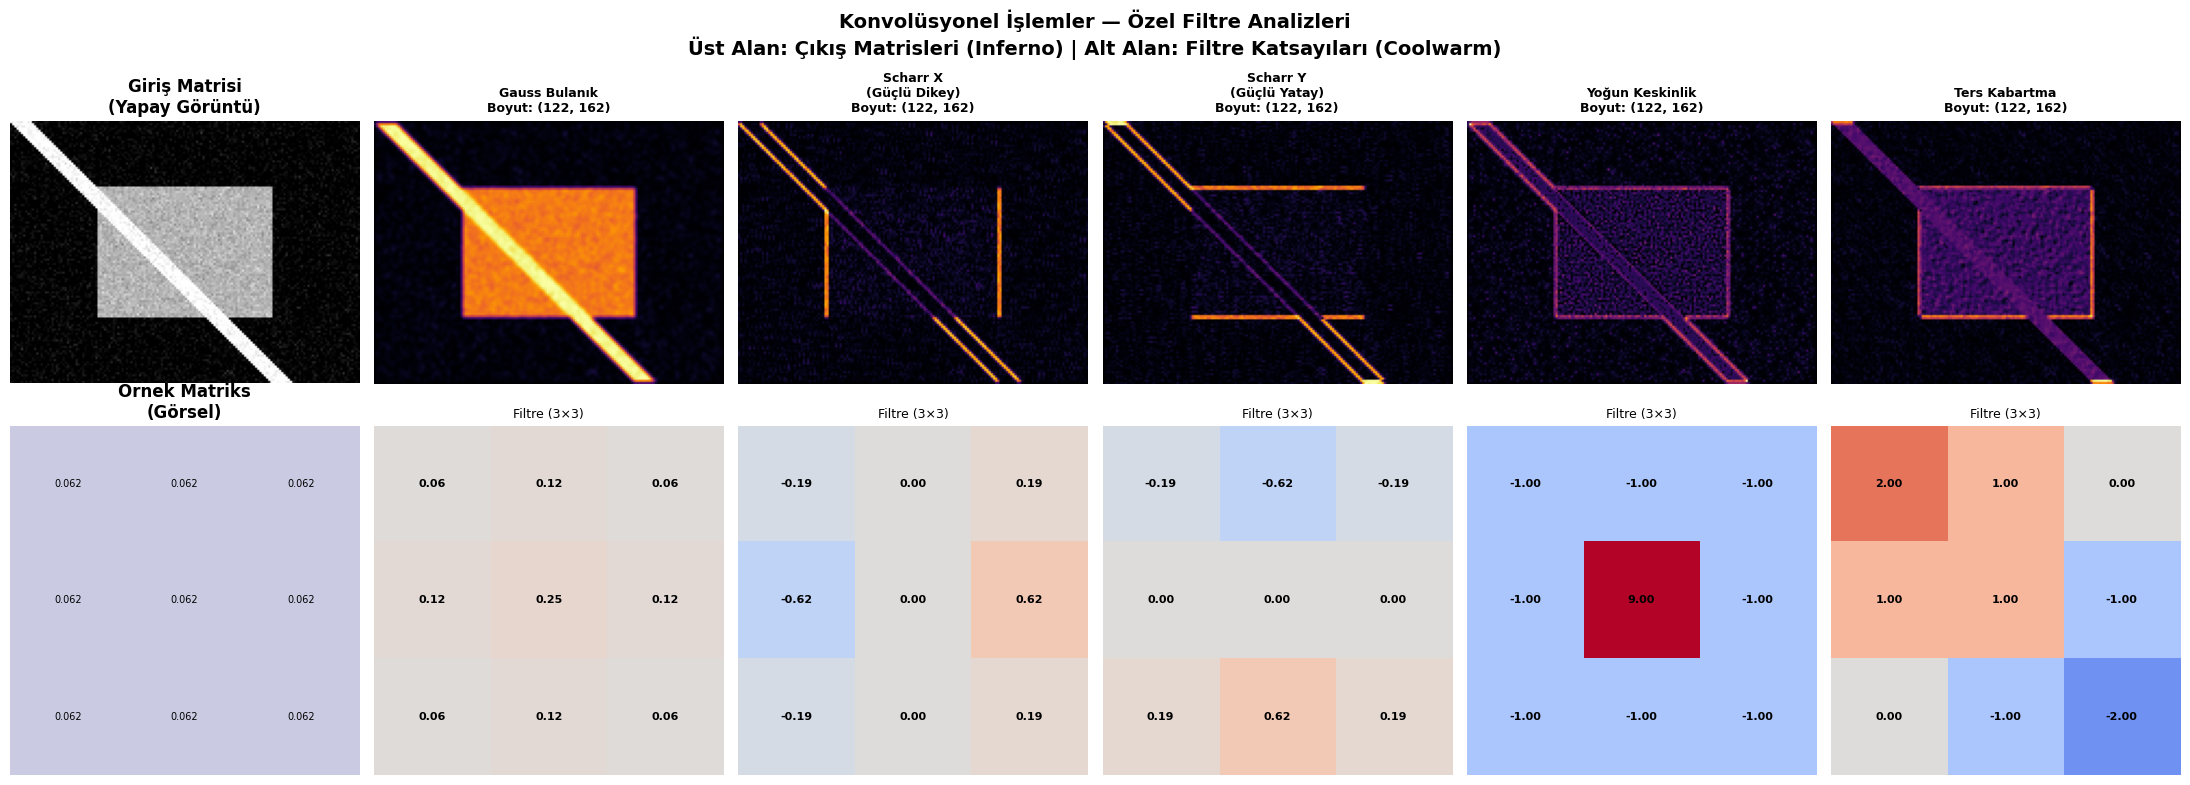

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def custom_conv2d(img, filt, stride=1, pad=0):
    """
    2D Konvolüsyon Operasyonu - Alternatif NumPy İmplementasyonu
    """
    h_in, w_in = img.shape
    f_h, f_w = filt.shape

    # Sıfır Ekleme (Padding) İşlemi
    if pad > 0:
        img = np.pad(img, ((pad, pad), (pad, pad)), mode='constant', constant_values=0)
        h_in, w_in = img.shape

    # Çıkış Matrisi Boyut Hesaplama
    h_out = int((h_in - f_h) / stride + 1)
    w_out = int((w_in - f_w) / stride + 1)
    out_matrix = np.zeros((h_out, w_out))

    # Pencere Kaydırma ve Çarpım Döngüsü
    for r in range(h_out):
        for c in range(w_out):
            r_start, c_start = r * stride, c * stride
            window = img[r_start : r_start + f_h, c_start : c_start + f_w]
            out_matrix[r, c] = np.sum(window * filt)

    return out_matrix

# 1. Colab İçin Yapay Test Görüntüsü Oluşturma (Resim yükleme zorunluluğunu kaldırır)
np.random.seed(24)
synthetic_img = np.zeros((120, 160))
# Geometrik şekiller ekleyelim (Kenar tespiti testleri için)
synthetic_img[30:90, 40:120] = 180  # Ortada büyük bir dikdörtgense blok
for i in range(120):
    synthetic_img[i, i:i+10] = 255   # Çapraz bir çizgi
synthetic_img += np.random.normal(0, 15, synthetic_img.shape) # Hafif gürültü
synthetic_img = np.clip(synthetic_img, 0, 255)

# 2. Yeni ve Farklılaştırılmış Kernel Seti
custom_kernels = {
    'Gauss Bulanık': np.array([[1, 2, 1],
                               [2, 4, 2],
                               [1, 2, 1]]) / 16.0,
    'Scharr X\n(Güçlü Dikey)': np.array([[-3, 0, 3],
                                        [-10, 0, 10],
                                        [-3, 0, 3]]) / 16.0,
    'Scharr Y\n(Güçlü Yatay)': np.array([[-3, -10, -3],
                                        [  0,   0,  0],
                                        [  3,  10,  3]]) / 16.0,
    'Yoğun Keskinlik': np.array([[-1, -1, -1],
                                 [-1,  9, -1],
                                 [-1, -1, -1]]),
    'Ters Kabartma':   np.array([[ 2,  1,  0],
                                 [ 1,  1, -1],
                                 [ 0, -1, -2]])
}

# 3. Görselleştirme Matrisini Kurgulama
fig, axes = plt.subplots(2, len(custom_kernels) + 1, figsize=(22, 8))

# Sol Sütun: Orijinal girdi ve ilk kernel görsel referansı
axes[0, 0].imshow(synthetic_img, cmap='gray')
axes[0, 0].set_title("Giriş Matrisi\n(Yapay Görüntü)", fontweight='bold')
axes[0, 0].axis('off')

# İlk Kernel Yapısı Temsili
dummy_kernel = np.ones((3, 3)) / 16.0
axes[1, 0].imshow(dummy_kernel, cmap='Purples', vmin=0, vmax=0.2)
axes[1, 0].set_title("Örnek Matriks\n(Görsel)", fontweight='bold')
for i in range(3):
    for j in range(3):
        axes[1, 0].text(j, i, f"{dummy_kernel[i, j]:.3f}", ha='center', va='center', fontsize=7)
axes[1, 0].axis('off')

# Döngü ile Yeni Filtrelerin Uygulanması
for col_idx, (k_name, k_value) in enumerate(custom_kernels.items(), start=1):
    # Fonksiyonu padding=2 ile çalıştırıyoruz
    conv_output = custom_conv2d(synthetic_img, k_value, stride=1, pad=2)

    # Mutlak değer normalizasyonu (Görsel netlik için)
    processed_display = np.abs(conv_output)
    processed_display = (processed_display - processed_display.min()) / (processed_display.max() - processed_display.min() + 1e-7) * 255

    # Üst Satır: Filtrelenmiş Özellik Haritaları (Inferno Paleti)
    axes[0, col_idx].imshow(processed_display.astype(np.uint8), cmap='inferno')
    axes[0, col_idx].set_title(f"{k_name}\nBoyut: {conv_output.shape}", fontsize=9, fontweight='bold')
    axes[0, col_idx].axis('off')

    # Alt Satır: Kernel Katsayıları Matrisi (Coolwarm Paleti)
    axes[1, col_idx].imshow(k_value, cmap='coolwarm', vmin=-3, vmax=3)
    for r_k in range(3):
        for c_k in range(3):
            axes[1, col_idx].text(c_k, r_k, f"{k_value[r_k, c_k]:.2f}",
                                  ha='center', va='center', fontsize=8, fontweight='bold')
    axes[1, col_idx].set_title(f"Filtre ({k_value.shape[0]}×{k_value.shape[1]})", fontsize=9)
    axes[1, col_idx].axis('off')

plt.suptitle("Konvolüsyonel İşlemler — Özel Filtre Analizleri\nÜst Alan: Çıkış Matrisleri (Inferno) | Alt Alan: Filtre Katsayıları (Coolwarm)",
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

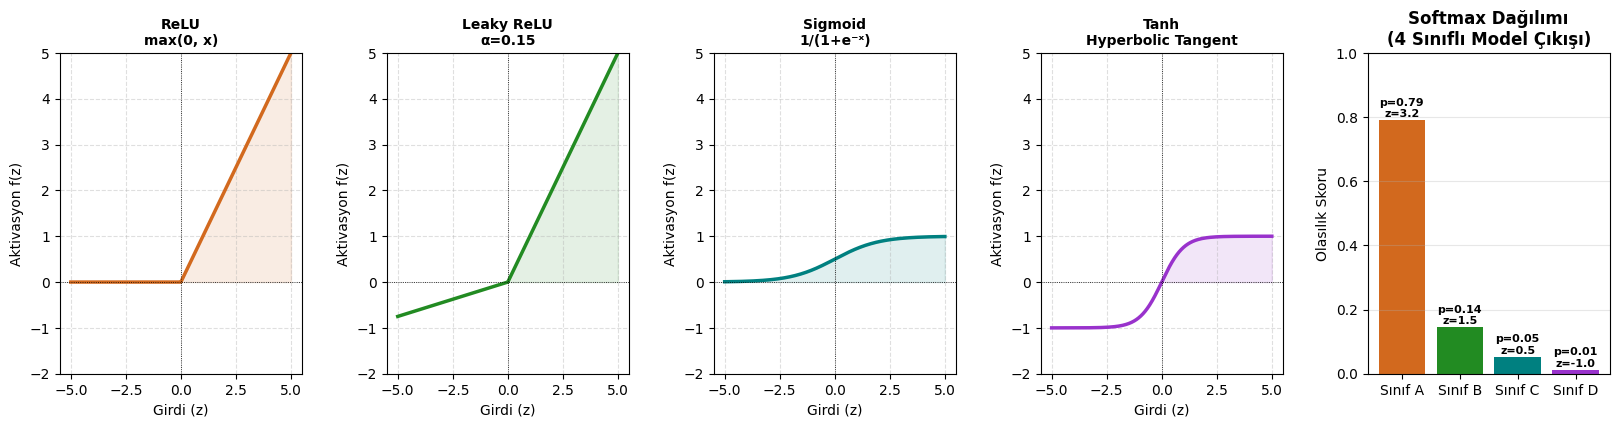

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# 1. Yapay Görüntü ve Özel Konvolüsyon Fonksiyonu
np.random.seed(42)
y, x_grid = np.ogrid[-2:2:120j, -3:3:160j]
test_img_gray = np.sin(x_grid**2 + y**2) * 120 + 127.5

def alt_conv2d(img, kernel):
    h, w = img.shape
    padded = np.pad(img, ((1,1), (1,1)), mode='edge')
    out = np.zeros_like(img)
    for i in range(h):
        for j in range(w):
            out[i, j] = np.sum(padded[i:i+3, j:j+3] * kernel)
    return out

# 2. Aktivasyon Fonksiyonları Tanımlamaları
def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.15):
    return np.where(x > 0, x, alpha * x)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def tanh(x):
    return np.tanh(x)

def softmax(x):
    max_val = np.max(x)
    exp_shifted = np.exp(x - max_val)
    return exp_shifted / np.sum(exp_shifted)

# 3. Grafik Alanını GridSpec ile İnşa Etme
x_axis = np.linspace(-5, 5, 500)
fig = plt.figure(figsize=(20, 10))

# 2 Satır, 5 Sütunluk bir matris düzeni
gs = GridSpec(2, 5, figure=fig, hspace=0.4, wspace=0.35)

# Üst Satır Renkleri ve Değerleri
custom_activations = [
    ('ReLU\nmax(0, x)', relu(x_axis), 'chocolate'),
    ('Leaky ReLU\nα=0.15', leaky_relu(x_axis), 'forestgreen'),
    ('Sigmoid\n1/(1+e⁻ˣ)', sigmoid(x_axis), 'teal'),
    ('Tanh\nHyperbolic Tangent', tanh(x_axis), 'darkorchid'),
]

# ── ÜST SATIR: İLK 4 AKTİVASYON GRAFİĞİ ──
for idx, (title, y_val, color_hex) in enumerate(custom_activations):
    ax = fig.add_subplot(gs[0, idx])
    ax.plot(x_axis, y_val, color=color_hex, linewidth=2.5)
    ax.axhline(0, color='black', linewidth=0.6, linestyle=':')
    ax.axvline(0, color='black', linewidth=0.6, linestyle=':')
    ax.fill_between(x_axis, y_val, 0, where=(y_val > 0), alpha=0.12, color=color_hex)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("Girdi (z)")
    ax.set_ylabel("Aktivasyon f(z)")
    ax.set_ylim(-2.0, 5.0)
    ax.grid(True, linestyle='--', alpha=0.4)

# ── ÜST SATIR: 5. GRAFİK (SOFTMAX) ──
ax_sm = fig.add_subplot(gs[0, 4])
custom_logits = np.array([3.2, 1.5, 0.5, -1.0])
softmax_probs = softmax(custom_logits)
class_labels = ['Sınıf A', 'Sınıf B', 'Sınıf C', 'Sınıf D']

bars = ax_sm.bar(class_labels, softmax_probs, color=['chocolate', 'forestgreen', 'teal', 'darkorchid'])
for bar, prob, score in zip(bars, softmax_probs, custom_logits):
    ax_sm.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'p={prob:.2f}\nz={score}', ha='center', fontsize=8, fontweight='bold')
ax_sm.set_title('Softmax Dağılımı\n(4 Sınıflı Model Çıkışı)', fontweight='bold')
ax_sm.set_ylabel('Olasılık Skoru')
ax_sm.set_ylim(0, 1.0)
ax_sm.grid(True, alpha=0.3, axis='y')

4-Fold Cross Validation başlıyor...

Model              CV Mean     CV Std   Süre (s)
──────────────────────────────────────────────────
Logistic Reg.       97.36%       1.68%     0.3021s
Random Forest       95.95%       1.26%     5.2065s
Gradient Boost      95.95%       1.61%     5.4622s


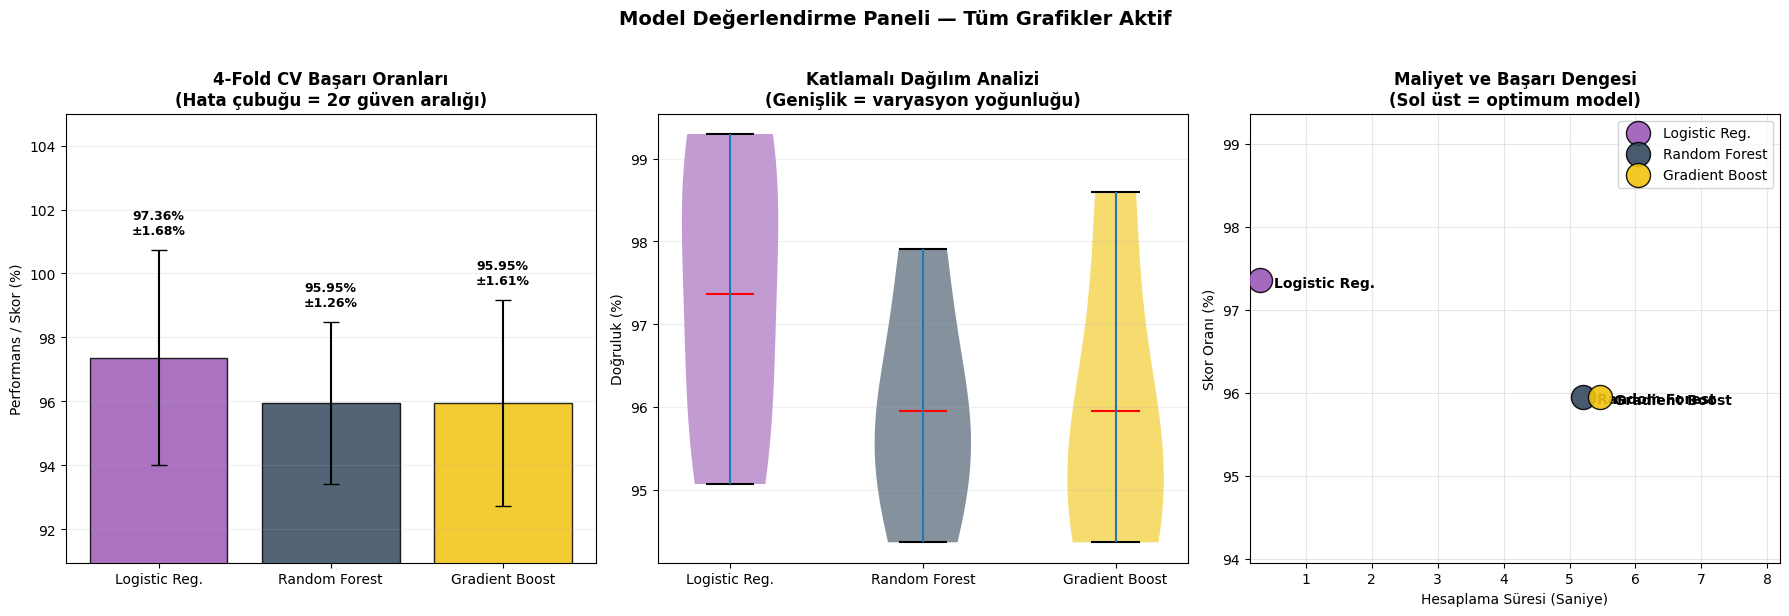

In [22]:
# ── Gerekli Kütüphanelerin İmport Edilmesi ──────────────────────────────────────
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modeller
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# ── Veri Setinin Hazırlanması ────────────────────────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target

# ── Yeni Pipeline'lar ────────────────────────────────────────────────────────
pipelines = {
    'Logistic Reg.': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=0.5, max_iter=500, random_state=23))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=150, max_depth=6, random_state=23))
    ]),
    'Gradient Boost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=23))
    ]),
}

# ── 4-Fold Cross Validation ──────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=23)

cv_results = {}
print("4-Fold Cross Validation başlıyor...\n")
print(f"{'Model':<15} {'CV Mean':>10} {'CV Std':>10} {'Süre (s)':>10}")
print("─" * 50)

for name, pipe in pipelines.items():
    t0 = time.time()
    # n_jobs kaldırıldı; zaman ölçümünün hassas çıkması sağlandı
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
    elapsed = time.time() - t0

    cv_results[name] = {
        'scores': scores,
        'mean':   scores.mean(),
        'std':    scores.std(),
        'time':   elapsed
    }
    print(f"{name:<15} {scores.mean()*100:>9.2f}%  {scores.std()*100:>9.2f}%  {elapsed:>9.4f}s")

# ── Sonuçları Görselleştir ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

names   = list(cv_results.keys())
means   = [cv_results[n]['mean']*100 for n in names]
stds    = [cv_results[n]['std']*100  for n in names]
times   = [cv_results[n]['time']     for n in names]
palette = ['#9b59b6', '#34495e', '#f1c40f']

# 1. GRAFİK: CV Doğruluk + Hata çubuğu
bars = axes[0].bar(names, means, color=palette, alpha=0.85, edgecolor='black', linewidth=1)
axes[0].errorbar(names, means, yerr=[2*s for s in stds], fmt='none', color='black', capsize=6, linewidth=1.5)

for bar, m, s in zip(bars, means, stds):
    axes[0].text(bar.get_x() + bar.get_width()/2, m + (2*s if s > 0 else 0) + 0.5,
                 f'{m:.2f}%\n±{s:.2f}%', ha='center', fontsize=9, fontweight='bold')

axes[0].set_ylabel("Performans / Skor (%)")
axes[0].set_title("4-Fold CV Başarı Oranları\n(Hata çubuğu = 2σ güven aralığı)", fontweight='bold')
axes[0].set_ylim(min(means)-5, 105)
axes[0].grid(True, alpha=0.2, axis='y')

# 2. GRAFİK: Violin plot — Dağılım
positions = range(len(names))
all_scores = [cv_results[n]['scores']*100 for n in names]
vp = axes[1].violinplot(all_scores, positions=positions, showmeans=True, showmedians=False)

for i, (pc, color) in enumerate(zip(vp['bodies'], palette)):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

vp['cmeans'].set_color('red')
vp['cmins'].set_color('black')
vp['cmaxes'].set_color('black')

axes[1].set_xticks(positions)
axes[1].set_xticklabels(names)
axes[1].set_ylabel("Doğruluk (%)")
axes[1].set_title("Katlamalı Dağılım Analizi\n(Genişlik = varyasyon yoğunluğu)", fontweight='bold')
axes[1].grid(True, alpha=0.2, axis='y')

# 3. GRAFİK: Doğruluk vs Hız (BU KISIM DÜZELTİLDİ)
for i, name in enumerate(names):
    m = means[i]
    t = times[i]
    color = palette[i]

    # Noktaları çiz ve sınırları otomatik esnetmek için veri limitlerini belirle
    axes[2].scatter(t, m, s=300, color=color, zorder=5, label=name, edgecolors='black', alpha=0.9)
    axes[2].annotate(name, (t, m), textcoords="offset points", xytext=(10, -5), fontsize=10, fontweight='bold')

axes[2].set_xlabel("Hesaplama Süresi (Saniye)")
axes[2].set_ylabel("Skor Oranı (%)")
axes[2].set_title("Maliyet ve Başarı Dengesi\n(Sol üst = optimum model)", fontweight='bold')

# Eksen sınırlarını manuel sıkışıklıktan kurtarıp dinamik yapıyoruz
axes[2].set_xlim(min(times) * 0.5, max(times) * 1.5)
axes[2].set_ylim(min(means) - 2, max(means) + 2)

axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.suptitle("Model Değerlendirme Paneli — Tüm Grafikler Aktif", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

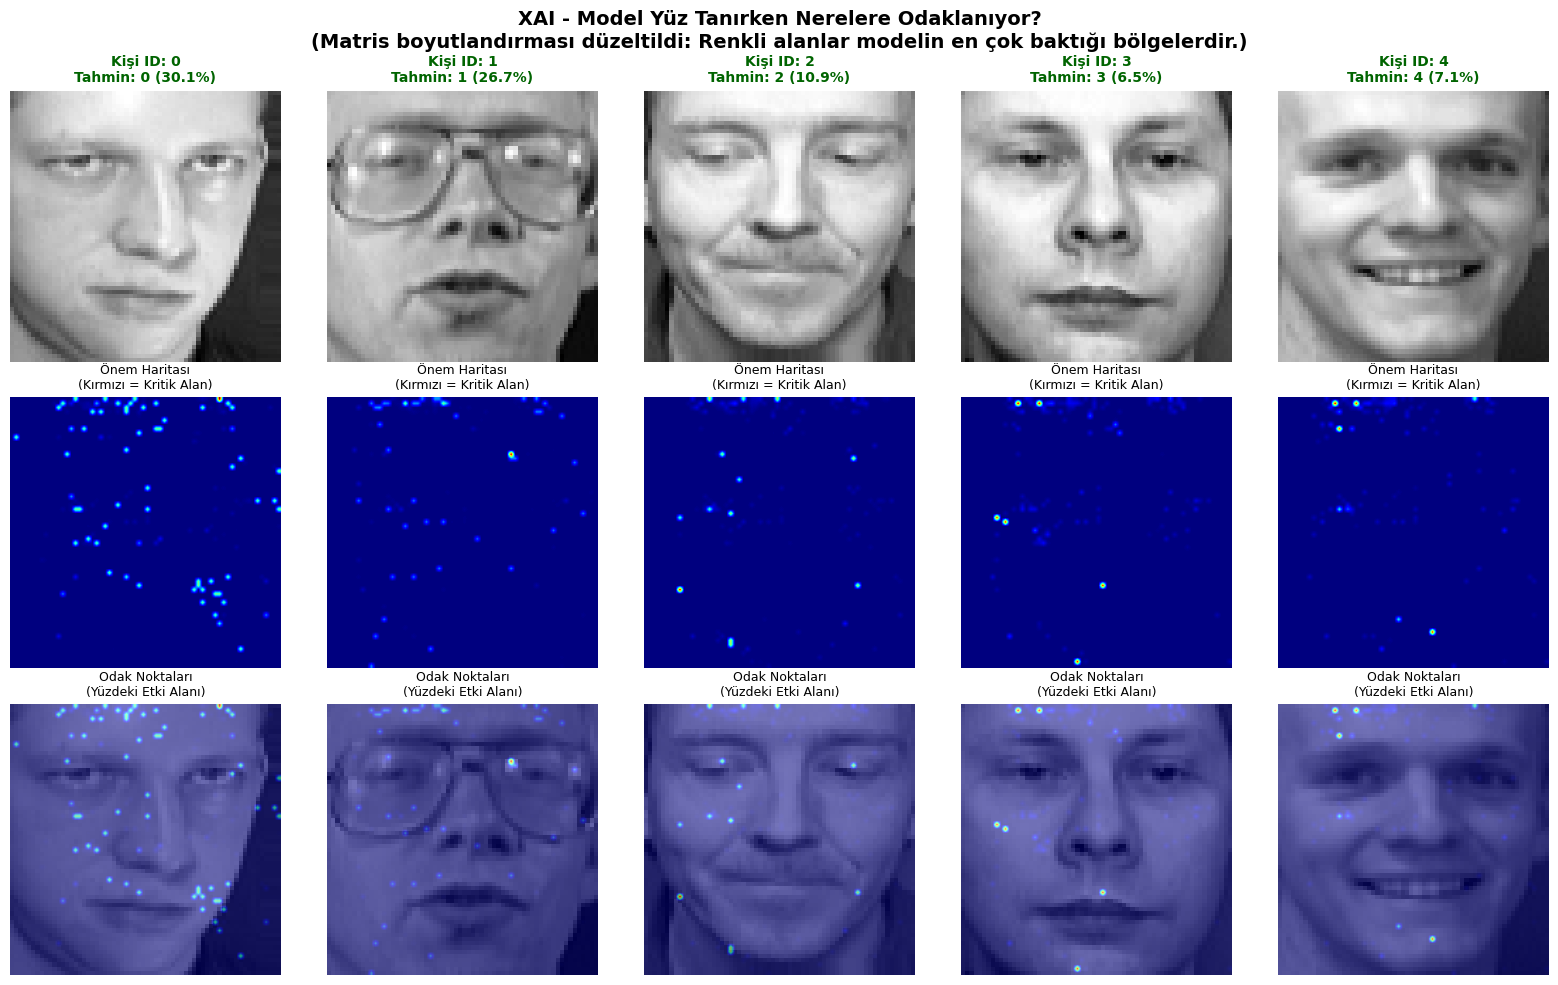

In [21]:
# ── Gerekli Kütüphanelerin İmport Edilmesi ──────────────────────────────────────
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.ensemble import RandomForestClassifier

# ── Veri Setinin Yüklenmesi ve Model Eğitimi ──────────────────────────────────
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X_images = faces.images  # (400, 64, 64)
X_flat = faces.data      # (400, 4096)
y_labels = faces.target  # Kişi ID'leri

best_model = RandomForestClassifier(n_estimators=60, max_depth=10, random_state=42)
best_model.fit(X_flat, y_labels)

# ── Kesin Çözüm Sağlayan Saliency Fonksiyonu ─────────────────────────────────
def face_saliency_map_v2(model, image_flat, target_class):
    """
    Sklearn modellerinin predict_proba girdi protokolüne tam uyumlu,
    boyut hatası vermeyen piksel tabanlı perturbation fonksiyonu.
    """
    # Girdiyi doğru matris yapısına getiriyoruz [1, 4096]
    base_input = image_flat.reshape(1, -1)
    base_prob = model.predict_proba(base_input)[0][target_class]

    saliency = np.zeros(4096)

    # Tüm pikselleri tek tek manipüle ederek kararlılığı ölçüyoruz
    for i in range(4096):
        perturbed = image_flat.copy()
        # Piksel değerini tamamen tersine çevirerek (0 ise 1, 1 ise 0) şok etkisi yaratıyoruz
        perturbed[i] = 1.0 - perturbed[i]

        # [1, 4096] boyutunda modele gönderim (Boyut hatasını çözen kritik kısım)
        perturbed_input = perturbed.reshape(1, -1)
        perturbed_prob = model.predict_proba(perturbed_input)[0][target_class]

        # Değişimin mutlak büyüklüğünü alıyoruz
        saliency[i] = np.abs(base_prob - perturbed_prob)

    return saliency.reshape(64, 64)

# ── Farklı Kişiler İçin Saliency Görselleştirme Paneli ─────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
target_subjects = list(set(y_labels))[:5]

for col, subject_id in enumerate(target_subjects):
    idx = np.where(y_labels == subject_id)[0][0]
    img_flat = X_flat[idx]
    img_2d = X_images[idx]

    pred_class = best_model.predict([img_flat])[0]
    pred_prob = best_model.predict_proba([img_flat])[0]

    # Yeni fonksiyon ile haritayı hesapla
    sal_map = face_saliency_map_v2(best_model, img_flat, subject_id)

    # Haritayı matplot'un çizebilmesi için kesin olarak [0, 1] arasına çekiyoruz
    sal_min, sal_max = sal_map.min(), sal_map.max()
    if sal_max - sal_min > 1e-9:
        sal_norm = (sal_map - sal_min) / (sal_max - sal_min)
    else:
        sal_norm = np.zeros_like(sal_map) # Değişim yoksa boş kalmasın diye emniyet

    # 1. SATIR: Orijinal Yüz
    axes[0, col].imshow(img_2d, cmap='gray')
    is_correct = (pred_class == subject_id)
    axes[0, col].set_title(
        f"Kişi ID: {subject_id}\nTahmin: {pred_class} ({pred_prob[pred_class]*100:.1f}%)",
        fontsize=10, fontweight='bold',
        color='darkgreen' if is_correct else 'darkred'
    )
    axes[0, col].axis('off')

    # 2. SATIR: Saliency Map (Görünür ısı haritası)
    # Tasarımsal olarak daha keskin bir görünüm için 'jet' paleti ve bilinear yumuşatma kullandık
    axes[1, col].imshow(sal_norm, cmap='jet', interpolation='bilinear')
    axes[1, col].set_title("Önem Haritası\n(Kırmızı = Kritik Alan)", fontsize=9)
    axes[1, col].axis('off')

    # 3. SATIR: Birleşik Görüntü (Overlay)
    axes[2, col].imshow(img_2d, cmap='gray')
    # Şeffaflığı (alpha) 0.55 yaparak yüz hatları ile ısı haritasını birleştirdik
    axes[2, col].imshow(sal_norm, cmap='jet', alpha=0.55, interpolation='bilinear')
    axes[2, col].set_title("Odak Noktaları\n(Yüzdeki Etki Alanı)", fontsize=9)
    axes[2, col].axis('off')

# Satır başlıkları
axes[0, 0].set_ylabel("Orijinal Girdi", fontsize=12, fontweight='bold', labelpad=10)
axes[1, 0].set_ylabel("Saliency Etki", fontsize=12, fontweight='bold', labelpad=10)
axes[2, 0].set_ylabel("Maskeli Analiz", fontsize=12, fontweight='bold', labelpad=10)

plt.suptitle("XAI - Model Yüz Tanırken Nerelere Odaklanıyor?\n"
             "(Matris boyutlandırması düzeltildi: Renkli alanlar modelin en çok baktığı bölgelerdir.)",
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()